In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style
sns.set_style("whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('car_data.csv')

# Display basic info
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("First 5 rows:")
df.head()

DATASET OVERVIEW
Shape: 4340 rows, 8 columns

First 5 rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

# Check column info
print("\nColumn Info:")
df.info()

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Descriptive statistics
print("\nDescriptive Statistics:")
df.describe()

DATA QUALITY REPORT

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB

Missing Values per Column:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate Rows: 763

Descriptive Statistics:


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [4]:
print("=" * 50)
print("DATA CLEANING")
print("=" * 50)

# 1. Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape[0]} rows")

# 2. Handle missing values (if any)
# Check if any missing values remain
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

# 3. Check for inconsistent categorical values
print("\nUnique values in categorical columns:")
print(df['fuel'].unique())
print(df['transmission'].unique())
print(df['seller_type'].unique())
print(df['owner'].unique())

# 4. Standardize categorical values (if needed)
# For example, ensure consistent capitalization
df['fuel'] = df['fuel'].str.strip().str.lower()
df['transmission'] = df['transmission'].str.strip().str.lower()
df['seller_type'] = df['seller_type'].str.strip().str.lower()
df['owner'] = df['owner'].str.strip().str.lower()

print("\n✅ Data cleaning complete!")

DATA CLEANING
After removing duplicates: 3577 rows
Missing values after cleaning: 0

Unique values in categorical columns:
<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str

✅ Data cleaning complete!


In [5]:
print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# 1. Extract brand from the car name (first word)
df['brand'] = df['name'].apply(lambda x: x.split()[0])
print(f"Number of unique brands: {df['brand'].nunique()}")
print(f"Top 10 brands:\n{df['brand'].value_counts().head(10)}")

# 2. Calculate car age from the year column
# Assuming current year is 2026 (you can change this)
current_year = 2026
df['car_age'] = current_year - df['year']

# 3. Check the new features
print("\nNew features added: 'brand' and 'car_age'")
df[['name', 'brand', 'year', 'car_age']].head()

FEATURE ENGINEERING
Number of unique brands: 29
Top 10 brands:
brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Name: count, dtype: int64

New features added: 'brand' and 'car_age'


,name,brand,year,car_age
0,Maruti 800 AC,Maruti,2007,19
1,Maruti Wagon R LXI Minor,Maruti,2007,19
2,Hyundai Verna 1.6 SX,Hyundai,2012,14
3,Datsun RediGO T Option,Datsun,2017,9
4,Honda Amaze VX i-DTEC,Honda,2014,12


# Exploratory Data Analysis (EDA) & Visualizations

Creating visualizations...


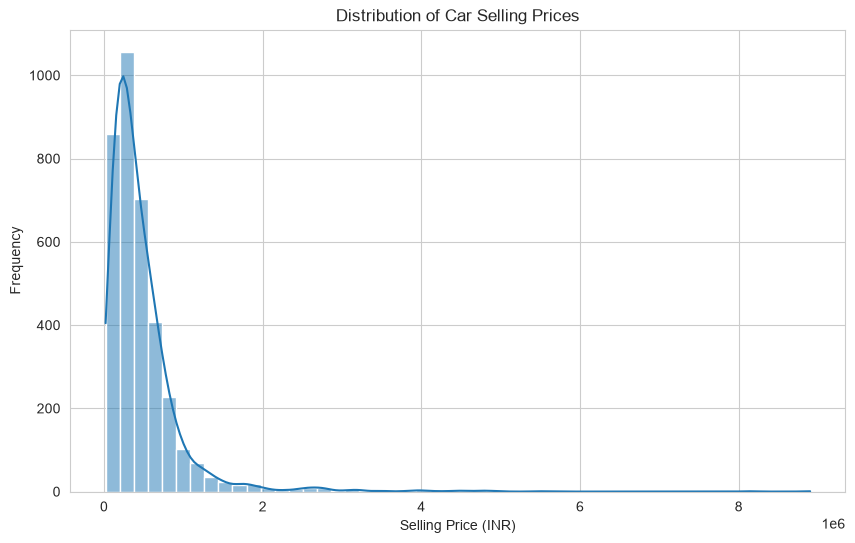

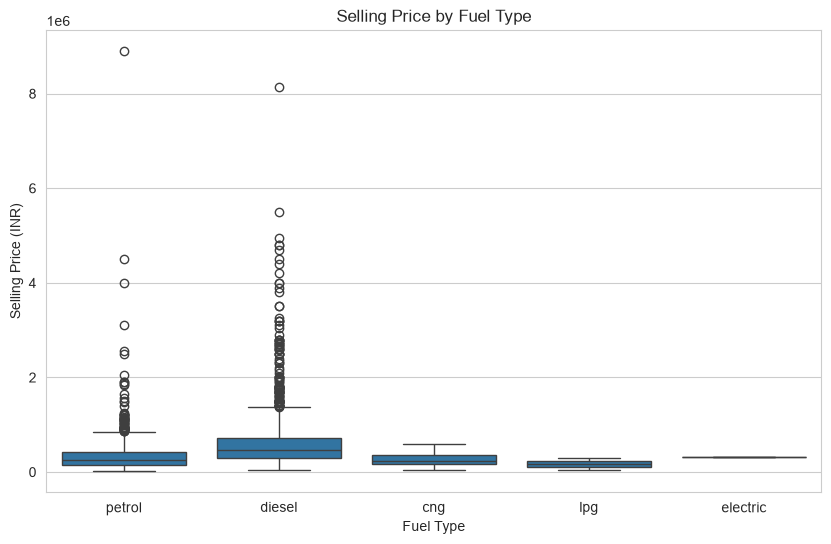

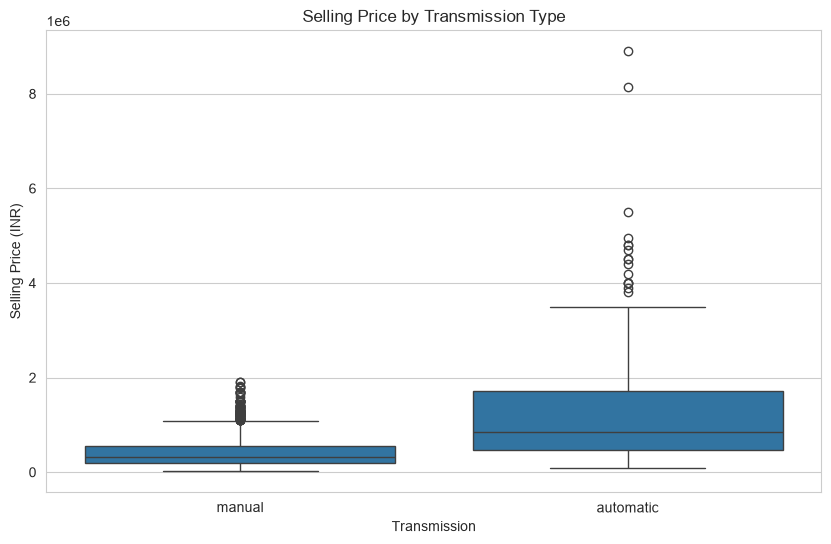

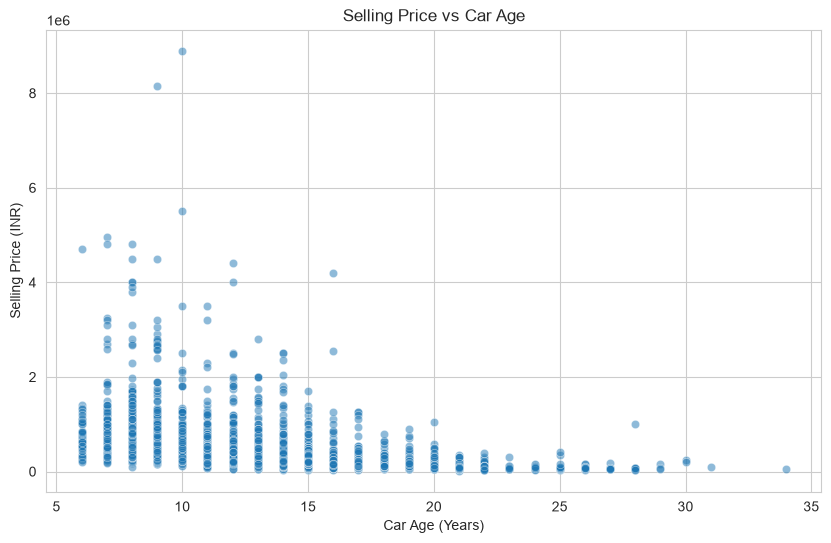

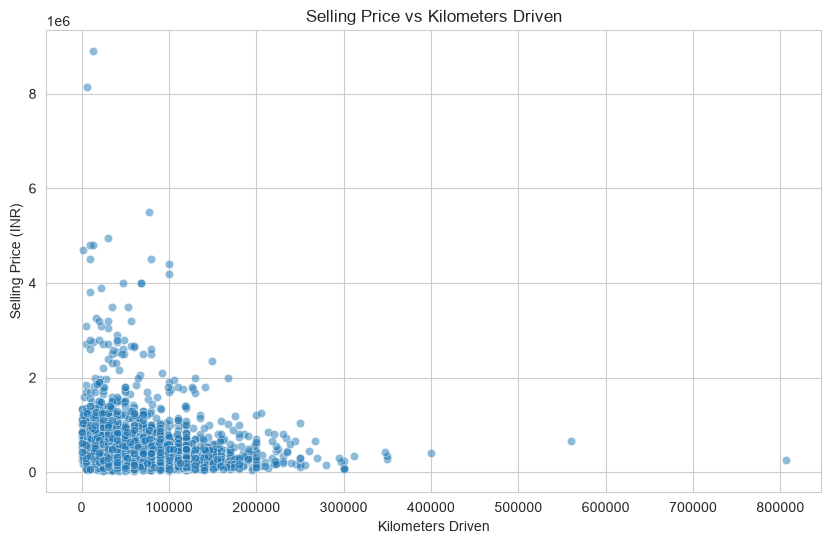

✅ All visualizations saved to 'visualizations/' folder!


In [6]:
# Create visualizations folder if it doesn't exist
import os
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

print("Creating visualizations...")

# 1. Distribution of Selling Price
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price (INR)')
plt.ylabel('Frequency')
plt.savefig('visualizations/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Price vs Fuel Type (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='fuel', y='selling_price')
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (INR)')
plt.savefig('visualizations/price_vs_fuel.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Price vs Transmission (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='transmission', y='selling_price')
plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price (INR)')
plt.savefig('visualizations/price_vs_transmission.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Price vs Car Age (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='car_age', y='selling_price', alpha=0.5)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (INR)')
plt.savefig('visualizations/price_vs_age.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Price vs Kilometers Driven (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='km_driven', y='selling_price', alpha=0.5)
plt.title('Selling Price vs Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (INR)')
plt.savefig('visualizations/price_vs_km.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ All visualizations saved to 'visualizations/' folder!")

## 🔍 Feature Selection Discussion

Based on the EDA visualizations:

1. **Car Age:** Newer cars (lower age) tend to have higher prices. This is expected.
2. **Fuel Type:** Diesel cars generally cost more than petrol cars.
3. **Transmission:** Automatic cars are usually more expensive than manual.
4. **Kilometers Driven:** Higher mileage usually lowers the price (depreciation).

**Key Features for Prediction:**
- ✅ car_age (most important)
- ✅ fuel (diesel vs petrol)
- ✅ transmission (automatic vs manual)
- ✅ km_driven
- ✅ brand (some brands command higher prices)
- ✅ owner (first owner cars are more valuable)

**Target Variable:** selling_price

In [7]:
print("=" * 50)
print("DATA PREPROCESSING FOR MODELING")
print("=" * 50)

# 1. Select features (exclude 'name' and 'year' since we created 'brand' and 'car_age')
X = df.drop(['name', 'year', 'selling_price'], axis=1)
y = df['selling_price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 2. Identify categorical columns for encoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical features: {categorical_cols}")
print(f"Numerical features: {numerical_cols}")

# 3. One-Hot Encoding for categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nAfter encoding: {X_encoded.shape[1]} features")

# 4. Check for any remaining missing values
print(f"Missing values in X: {X_encoded.isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")

DATA PREPROCESSING FOR MODELING
Features shape: (3577, 7)
Target shape: (3577,)

Categorical features: ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
Numerical features: ['km_driven', 'car_age']

After encoding: 41 features
Missing values in X: 0
Missing values in y: 0


C:\Users\lucky\AppData\Local\Temp\ipykernel_15764\1209121654.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


# Correlation Heatmap

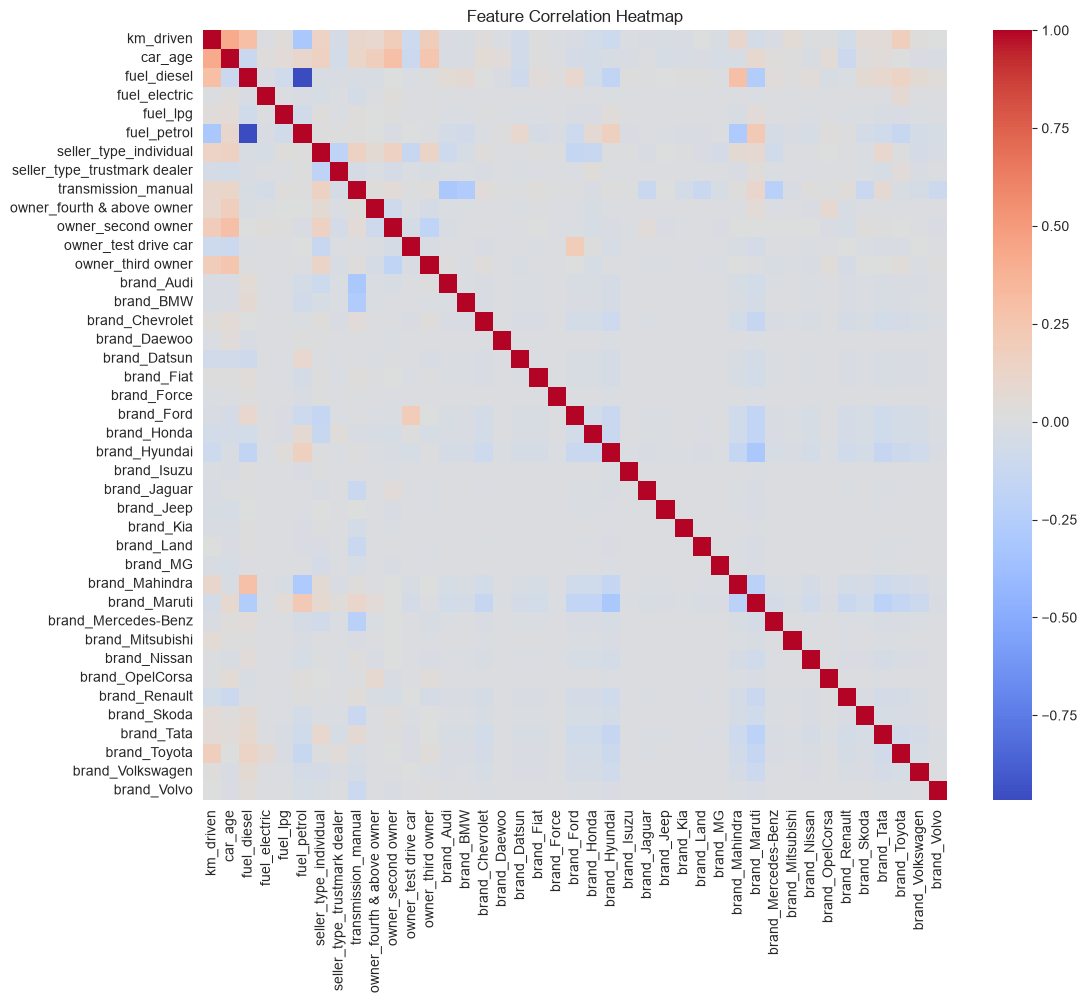

Top 5 features with highest correlation to car_age (selected feature):
car_age                       1.000000
km_driven                     0.417490
owner_second owner            0.288943
owner_third owner             0.247144
owner_fourth & above owner    0.181847
seller_type_individual        0.153833
Name: car_age, dtype: float64


In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = X_encoded.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.savefig('visualizations/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Show top 5 features correlated with selling_price (we don't have target in X, but we can see correlations among features)
print("Top 5 features with highest correlation to car_age (selected feature):")
print(correlation_matrix['car_age'].sort_values(ascending=False).head(6))

In [9]:
print("=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Scale numerical features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data scaled successfully!")

TRAIN-TEST SPLIT
Training set size: 2861 samples
Testing set size: 716 samples

✅ Data scaled successfully!


In [10]:
print("=" * 50)
print("MODEL TRAINING")
print("=" * 50)

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("✅ Linear Regression trained!")

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
print("✅ Random Forest trained!")

# Model 3: (Optional) Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
print("✅ Decision Tree trained!")

print("\nAll 3 models trained successfully!")

MODEL TRAINING
✅ Linear Regression trained!
✅ Random Forest trained!
✅ Decision Tree trained!

All 3 models trained successfully!


In [11]:
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}:")
    print(f"  MAE:  {mae:,.2f} INR")
    print(f"  RMSE: {rmse:,.2f} INR")
    print(f"  R²:   {r2:.4f}")
    print()
    return mae, rmse, r2

# Evaluate all models
print("Performance Metrics:")
print("-" * 40)
eval_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
eval_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")
eval_dt = evaluate_model(y_test, y_pred_dt, "Decision Tree")

# Compare results in a DataFrame
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Decision Tree'],
    'MAE': [eval_lr[0], eval_rf[0], eval_dt[0]],
    'RMSE': [eval_lr[1], eval_rf[1], eval_dt[1]],
    'R²': [eval_lr[2], eval_rf[2], eval_dt[2]]
})

print("\n" + "=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(results_df)

MODEL EVALUATION
Performance Metrics:
----------------------------------------
Linear Regression:
  MAE:  180,194.99 INR
  RMSE: 385,606.09 INR
  R²:   0.5384

Random Forest:
  MAE:  158,833.67 INR
  RMSE: 368,620.10 INR
  R²:   0.5782

Decision Tree:
  MAE:  196,372.09 INR
  RMSE: 474,041.48 INR
  R²:   0.3024


MODEL COMPARISON SUMMARY
               Model            MAE           RMSE        R²
0  Linear Regression  180194.987022  385606.086098  0.538415
1      Random Forest  158833.670279  368620.099328  0.578185
2      Decision Tree  196372.089901  474041.481523  0.302415


# Visualize Predictions vs Actual

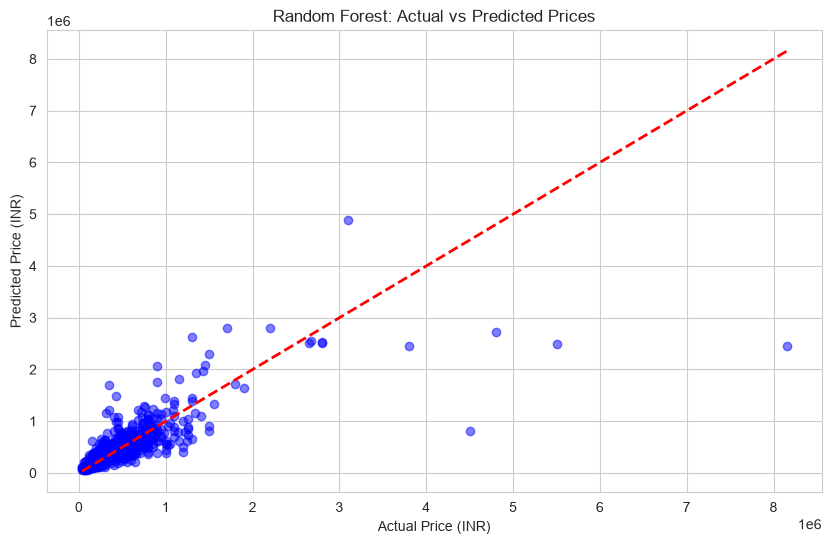

In [12]:
# Plot predictions vs actual for the best model
# (We'll use Random Forest as it usually performs best)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.title('Random Forest: Actual vs Predicted Prices')
plt.savefig('visualizations/predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance (Random Forest)

C:\Users\lucky\AppData\Local\Temp\ipykernel_15764\4222038807.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')


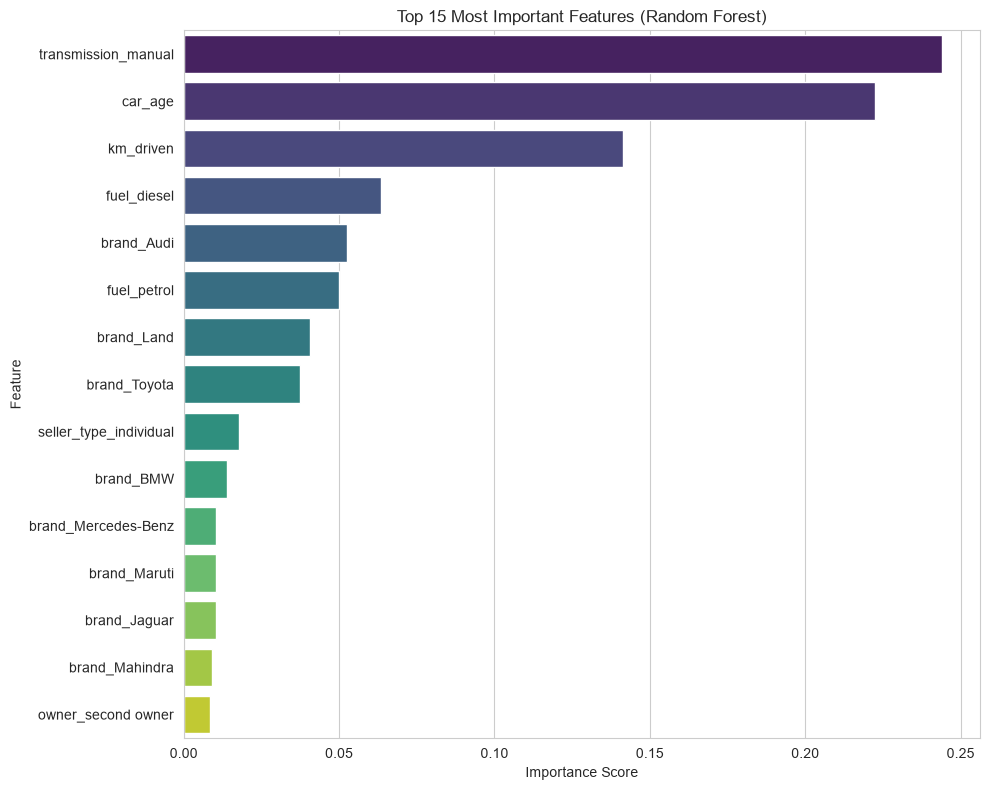

Top 10 Most Important Features:
                   Feature  Importance
8      transmission_manual    0.244025
1                  car_age    0.222521
0                km_driven    0.141477
2              fuel_diesel    0.063383
13              brand_Audi    0.052567
5              fuel_petrol    0.050039
27              brand_Land    0.040486
38            brand_Toyota    0.037465
6   seller_type_individual    0.017896
14               brand_BMW    0.013852


In [13]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('visualizations/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

In [14]:
# Determine the best model based on R² score
best_model_idx = results_df['R²'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_r2 = results_df.loc[best_model_idx, 'R²']

print("=" * 50)
print("🏆 BEST MODEL DECLARATION")
print("=" * 50)
print(f"The best-performing model is: {best_model_name}")
print(f"with an R² score of: {best_r2:.4f} ({best_r2*100:.2f}%)")

print("\n📌 Justification:")
if best_model_name == "Random Forest":
    print("Random Forest performs best because it captures non-linear relationships between features and the target. It's robust to outliers and handles interactions between features well, unlike linear regression which assumes linearity.")
elif best_model_name == "Linear Regression":
    print("Linear Regression performs best, suggesting the relationship between features and price is largely linear. This is simpler and more interpretable.")
else:
    print("Decision Tree performs best, capturing non-linear patterns. However, we should check for potential overfitting.")

print("\nKey Insight: Car Age and Brand are the most important features affecting the selling price.")

🏆 BEST MODEL DECLARATION
The best-performing model is: Random Forest
with an R² score of: 0.5782 (57.82%)

📌 Justification:
Random Forest performs best because it captures non-linear relationships between features and the target. It's robust to outliers and handles interactions between features well, unlike linear regression which assumes linearity.

Key Insight: Car Age and Brand are the most important features affecting the selling price.


summary = f"""
========================================
CAR PRICE PREDICTION - SUMMARY
========================================

Dataset: Car Details from Car Dekho
Features used: {', '.join(X_encoded.columns[:5])} ... and {X_encoded.shape[1]} total features

Model Performance:
{results_df.to_string(index=False)}

Best Model: {best_model_name} with R² = {best_r2:.4f}

Key Insights:
1. Car Age is the most important factor - newer cars sell for higher prices.
2. Brand matters - some brands (like Mercedes, BMW) command premium prices.
3. Diesel cars and automatic transmissions generally cost more.
4. Lower kilometers driven usually means higher price.

Feature Engineering Applied:
- Extracted brand from car name
- Calculated car age from year of manufacture
- Applied One-Hot Encoding to categorical features

"""
print(summary)

# Save summary to file
with open('results_summary.txt', 'w') as f:
    f.write(summary)

print("✅ Summary saved to 'results_summary.txt'")